In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Flatten,
                                      Dense, Dropout, BatchNormalization)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import image_dataset_from_directory

In [3]:
base_path = "/kaggle/input/datasets/jehanbhathena/weather-dataset"

def find_data_dir(root):
    for dirpath, dirnames, filenames in os.walk(root):
        if dirnames and not filenames:
            sub_has_images = any(
                any(f.lower().endswith(('.jpg', '.jpeg', '.png')) for f in os.listdir(os.path.join(dirpath, d)))
                for d in dirnames
            )
            if sub_has_images:
                return dirpath
    return root

data_dir = find_data_dir(base_path)
print("data_dir:", data_dir)
print("classes:", sorted(os.listdir(data_dir)))

data_dir: /kaggle/input/datasets/jehanbhathena/weather-dataset/dataset
classes: ['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']


In [4]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 64
SEED = 42
NUM_CLASSES = len(os.listdir(data_dir))

train_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
)

val_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
)

class_names = train_ds.class_names
print('class_names:', class_names)
print('num classes:', NUM_CLASSES)

Found 6862 files belonging to 11 classes.
Using 5490 files for training.


2026-08-16 20:53:27.836656: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 6862 files belonging to 11 classes.
Using 1372 files for validation.
class_names: ['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']
num classes: 11


In [5]:
val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

print("train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("val batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("test batches:", tf.data.experimental.cardinality(test_ds).numpy())

train batches: 86
val batches: 11
test batches: 11


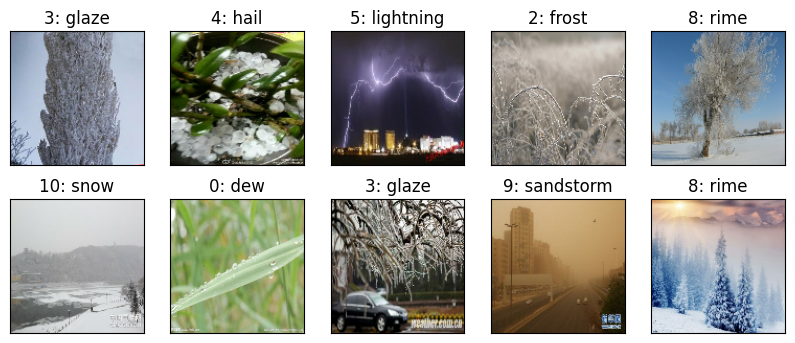

In [6]:
plt.figure(figsize=(10, 4))
for images, labels in test_ds.take(1):
    imgs = images.numpy()[:10].astype('uint8')
    lbls = np.argmax(labels.numpy()[:10], axis=1)
    for i, (img, y) in enumerate(zip(imgs, lbls)):
        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        plt.xticks([])
        plt.yticks([])
        plt.title(str(y) + ": " + class_names[y])
plt.show()

## Rescale + Cache/Prefetch

In [7]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

rescale = layers.Rescaling(1./255)

In [11]:
inpt_dim = (IMG_SIZE[0], IMG_SIZE[1], 3)
inpt_img = Input(shape=inpt_dim)

x = rescale(inpt_img)

# Convolutional layer 1
c11 = Conv2D(64, (9, 9), strides=(2, 2), activation='relu')(x)
p12 = MaxPooling2D(pool_size=(2, 2))(c11)
bn13 = BatchNormalization()(p12)

# Convolutional layer 2
c14 = Conv2D(128, (3, 3), strides=(1, 1), activation='relu')(bn13)
p15 = MaxPooling2D(pool_size=(2, 2))(c14)
bn16 = BatchNormalization()(p15)

# Flatten + Dense + Dropout
f17 = Flatten()(bn16)
do18 = Dropout(0.5)(f17)
d19 = Dense(units=256, activation='relu')(do18)
do110 = Dropout(0.2)(d19)
d111 = Dense(units=64, activation='relu')(do110)
do112 = Dropout(0.1)(d111)
output = Dense(units=NUM_CLASSES, activation='softmax')(do112)

classifier = Model(inpt_img, output)

In [12]:
opt = RMSprop(learning_rate=0.001)
classifier.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
classifier.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 60, 60, 64)     │        15,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 30, 30, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 11)             │           715 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,530,187 (24.91 MB)

 Trainable params: 6,529,803 (24.91 MB)

 Non-trainable params: 384 (1.50 KB)

In [13]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10,
                               min_delta=1e-4, mode='min', verbose=1)

stop_alg = EarlyStopping(monitor='val_loss', patience=35,
                          restore_best_weights=True, verbose=1)

checkpoint_filepath = 'weather_cnn_model.h5'
model_checkpoint = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True)

hist = classifier.fit(train_ds, epochs=30,
                       callbacks=[stop_alg, reduce_lr, model_checkpoint],
                       validation_data=val_ds)

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 682ms/step - accuracy: 0.3015 - loss: 5.3270

86/86 ━━━━━━━━━━━━━━━━━━━━ 82s 747ms/step - accuracy: 0.3623 - loss: 3.5199 - val_accuracy: 0.3039 - val_loss: 2.1929 - learning_rate: 0.0010
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 61s 704ms/step - accuracy: 0.4423 - loss: 1.8828 - val_accuracy: 0.2665 - val_loss: 2.9575 - learning_rate: 0.0010
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 667ms/step - accuracy: 0.5061 - loss: 1.6558

86/86 ━━━━━━━━━━━━━━━━━━━━ 60s 692ms/step - accuracy: 0.5036 - loss: 1.6377 - val_accuracy: 0.3728 - val_loss: 2.3953 - learning_rate: 0.0010
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 670ms/step - accuracy: 0.5405 - loss: 1.5136

86/86 ━━━━━━━━━━━━━━━━━━━━ 60s 695ms/step - accuracy: 0.5454 - loss: 1.4946 - val_accuracy: 0.4371 - val_loss: 1.9592 - learning_rate: 0.0010
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 60s 701ms/step - accuracy: 0.6038 - loss: 1.3131 - val_accuracy: 0.3907 - val_loss: 2.9481 - learning_rate: 0.0010
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 680ms/step - accuracy: 0.6431 - loss: 1.1611

86/86 ━━━━━━━━━━━━━━━━━━━━ 61s 711ms/step - accuracy: 0.6315 - loss: 1.1934 - val_accuracy: 0.5629 - val_loss: 1.5917 - learning_rate: 0.0010
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 61s 708ms/step - accuracy: 0.6721 - loss: 1.0603 - val_accuracy: 0.4147 - val_loss: 1.8755 - learning_rate: 0.0010
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 61s 707ms/step - accuracy: 0.6989 - loss: 0.9497 - val_accuracy: 0.5599 - val_loss: 1.7195 - learning_rate: 0.0010
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 81s 698ms/step - accuracy: 0.7200 - loss: 0.8745 - val_accuracy: 0.3099 - val_loss: 2.4159 - learning_rate: 0.0010
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 60s 704ms/step - accuracy: 0.7525 - loss: 0.7758 - val_accuracy: 0.5629 - val_loss: 2.2259 - learning_rate: 0.0010
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 60s 700ms/step - accuracy: 0.7787 - loss: 0.7136 - val_accuracy: 0.5479 - val_loss: 1.6699 - learning_rate: 0.0010
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - accuracy: 0.8068 - loss: 0.6114

86/86 ━━━━━━━━━━━━━━━━━━━━ 61s 704ms/step - accuracy: 0.8002 - loss: 0.6389 - val_accuracy: 0.6542 - val_loss: 1.3716 - learning_rate: 0.0010
Epoch 13/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 60s 700ms/step - accuracy: 0.8199 - loss: 0.5712 - val_accuracy: 0.5763 - val_loss: 2.1506 - learning_rate: 0.0010
Epoch 14/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 61s 706ms/step - accuracy: 0.8390 - loss: 0.5064 - val_accuracy: 0.5569 - val_loss: 3.0424 - learning_rate: 0.0010
Epoch 15/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 60s 703ms/step - accuracy: 0.8508 - loss: 0.4592 - val_accuracy: 0.6003 - val_loss: 1.5731 - learning_rate: 0.0010
Epoch 16/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - accuracy: 0.8709 - loss: 0.4133

86/86 ━━━━━━━━━━━━━━━━━━━━ 60s 703ms/step - accuracy: 0.8740 - loss: 0.4291 - val_accuracy: 0.6722 - val_loss: 1.7040 - learning_rate: 0.0010
Epoch 17/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 60s 700ms/step - accuracy: 0.8865 - loss: 0.4151 - val_accuracy: 0.6497 - val_loss: 1.9521 - learning_rate: 0.0010
Epoch 18/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 677ms/step - accuracy: 0.8952 - loss: 0.3474

86/86 ━━━━━━━━━━━━━━━━━━━━ 82s 701ms/step - accuracy: 0.8874 - loss: 0.3614 - val_accuracy: 0.6856 - val_loss: 1.8117 - learning_rate: 0.0010
Epoch 19/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 60s 697ms/step - accuracy: 0.8984 - loss: 0.3500 - val_accuracy: 0.6707 - val_loss: 1.4257 - learning_rate: 0.0010
Epoch 20/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 677ms/step - accuracy: 0.9084 - loss: 0.3640

86/86 ━━━━━━━━━━━━━━━━━━━━ 60s 702ms/step - accuracy: 0.9040 - loss: 0.3542 - val_accuracy: 0.7156 - val_loss: 2.0461 - learning_rate: 0.0010
Epoch 21/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 60s 694ms/step - accuracy: 0.9106 - loss: 0.3022 - val_accuracy: 0.6632 - val_loss: 1.9647 - learning_rate: 0.0010
Epoch 22/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 668ms/step - accuracy: 0.9245 - loss: 0.2475
Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
86/86 ━━━━━━━━━━━━━━━━━━━━ 82s 692ms/step - accuracy: 0.9235 - loss: 0.2645 - val_accuracy: 0.6452 - val_loss: 2.2103 - learning_rate: 0.0010
Epoch 23/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 60s 702ms/step - accuracy: 0.9393 - loss: 0.1841 - val_accuracy: 0.7036 - val_loss: 2.2652 - learning_rate: 5.0000e-04
Epoch 24/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 61s 708ms/step - accuracy: 0.9470 - loss: 0.1616 - val_accuracy: 0.6766 - val_loss: 2.3103 - learning_rate: 5.0000e-04
Epoch 25/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 60s 695ms/step - accuracy: 0.9561 - loss: 0

In [14]:
classifier.save_weights("weather_cnn1.weights.h5")

In [16]:
classifier.load_weights('weather_cnn1.weights.h5')

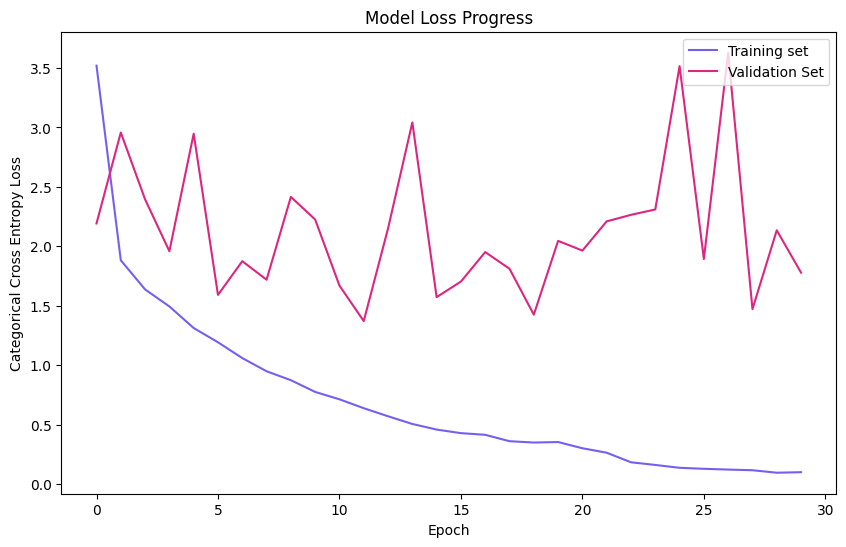

In [17]:
fig = plt.figure(figsize=(10, 6))
plt.plot(hist.history['loss'], color='#785ef0')
plt.plot(hist.history['val_loss'], color='#dc267f')
plt.title('Model Loss Progress')
plt.ylabel('Categorical Cross Entropy Loss')
plt.xlabel('Epoch')
plt.legend(['Training set', 'Validation Set'], loc='upper right')
plt.show()

In [18]:
classifier = keras.models.load_model('weather_cnn_model.h5')
classifier.compile(optimizer=RMSprop(), loss='categorical_crossentropy', metrics=['accuracy'])

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = classifier.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
labels_idx = list(range(NUM_CLASSES))

print(classification_report(y_true, y_pred, labels=labels_idx, target_names=class_names))

cm = confusion_matrix(y_true, y_pred, labels=labels_idx)
print(cm)

ber = 1 - balanced_accuracy_score(y_true, y_pred)
print('BER', ber)

              precision    recall  f1-score   support

         dew       0.83      0.79      0.81        61
     fogsmog       0.75      0.78      0.77        78
       frost       0.56      0.57      0.56        51
       glaze       0.62      0.62      0.62        66
        hail       0.68      0.56      0.61        61
   lightning       0.72      0.96      0.83        54
        rain       0.60      0.63      0.62        46
     rainbow       0.67      0.62      0.64        29
        rime       0.77      0.72      0.74       141
   sandstorm       0.75      0.75      0.75        61
        snow       0.45      0.45      0.45        56

    accuracy                           0.69       704
   macro avg       0.67      0.68      0.67       704
weighted avg       0.69      0.69      0.69       704

[[ 48   0   2   1   1   3   1   0   3   1   1]
 [  0  61   0   1   1   3   0   1   3   8   0]
 [  3   1  29   7   3   0   1   0   5   0   2]
 [  1   0   5  41   3   0   2   1   7   1   5]

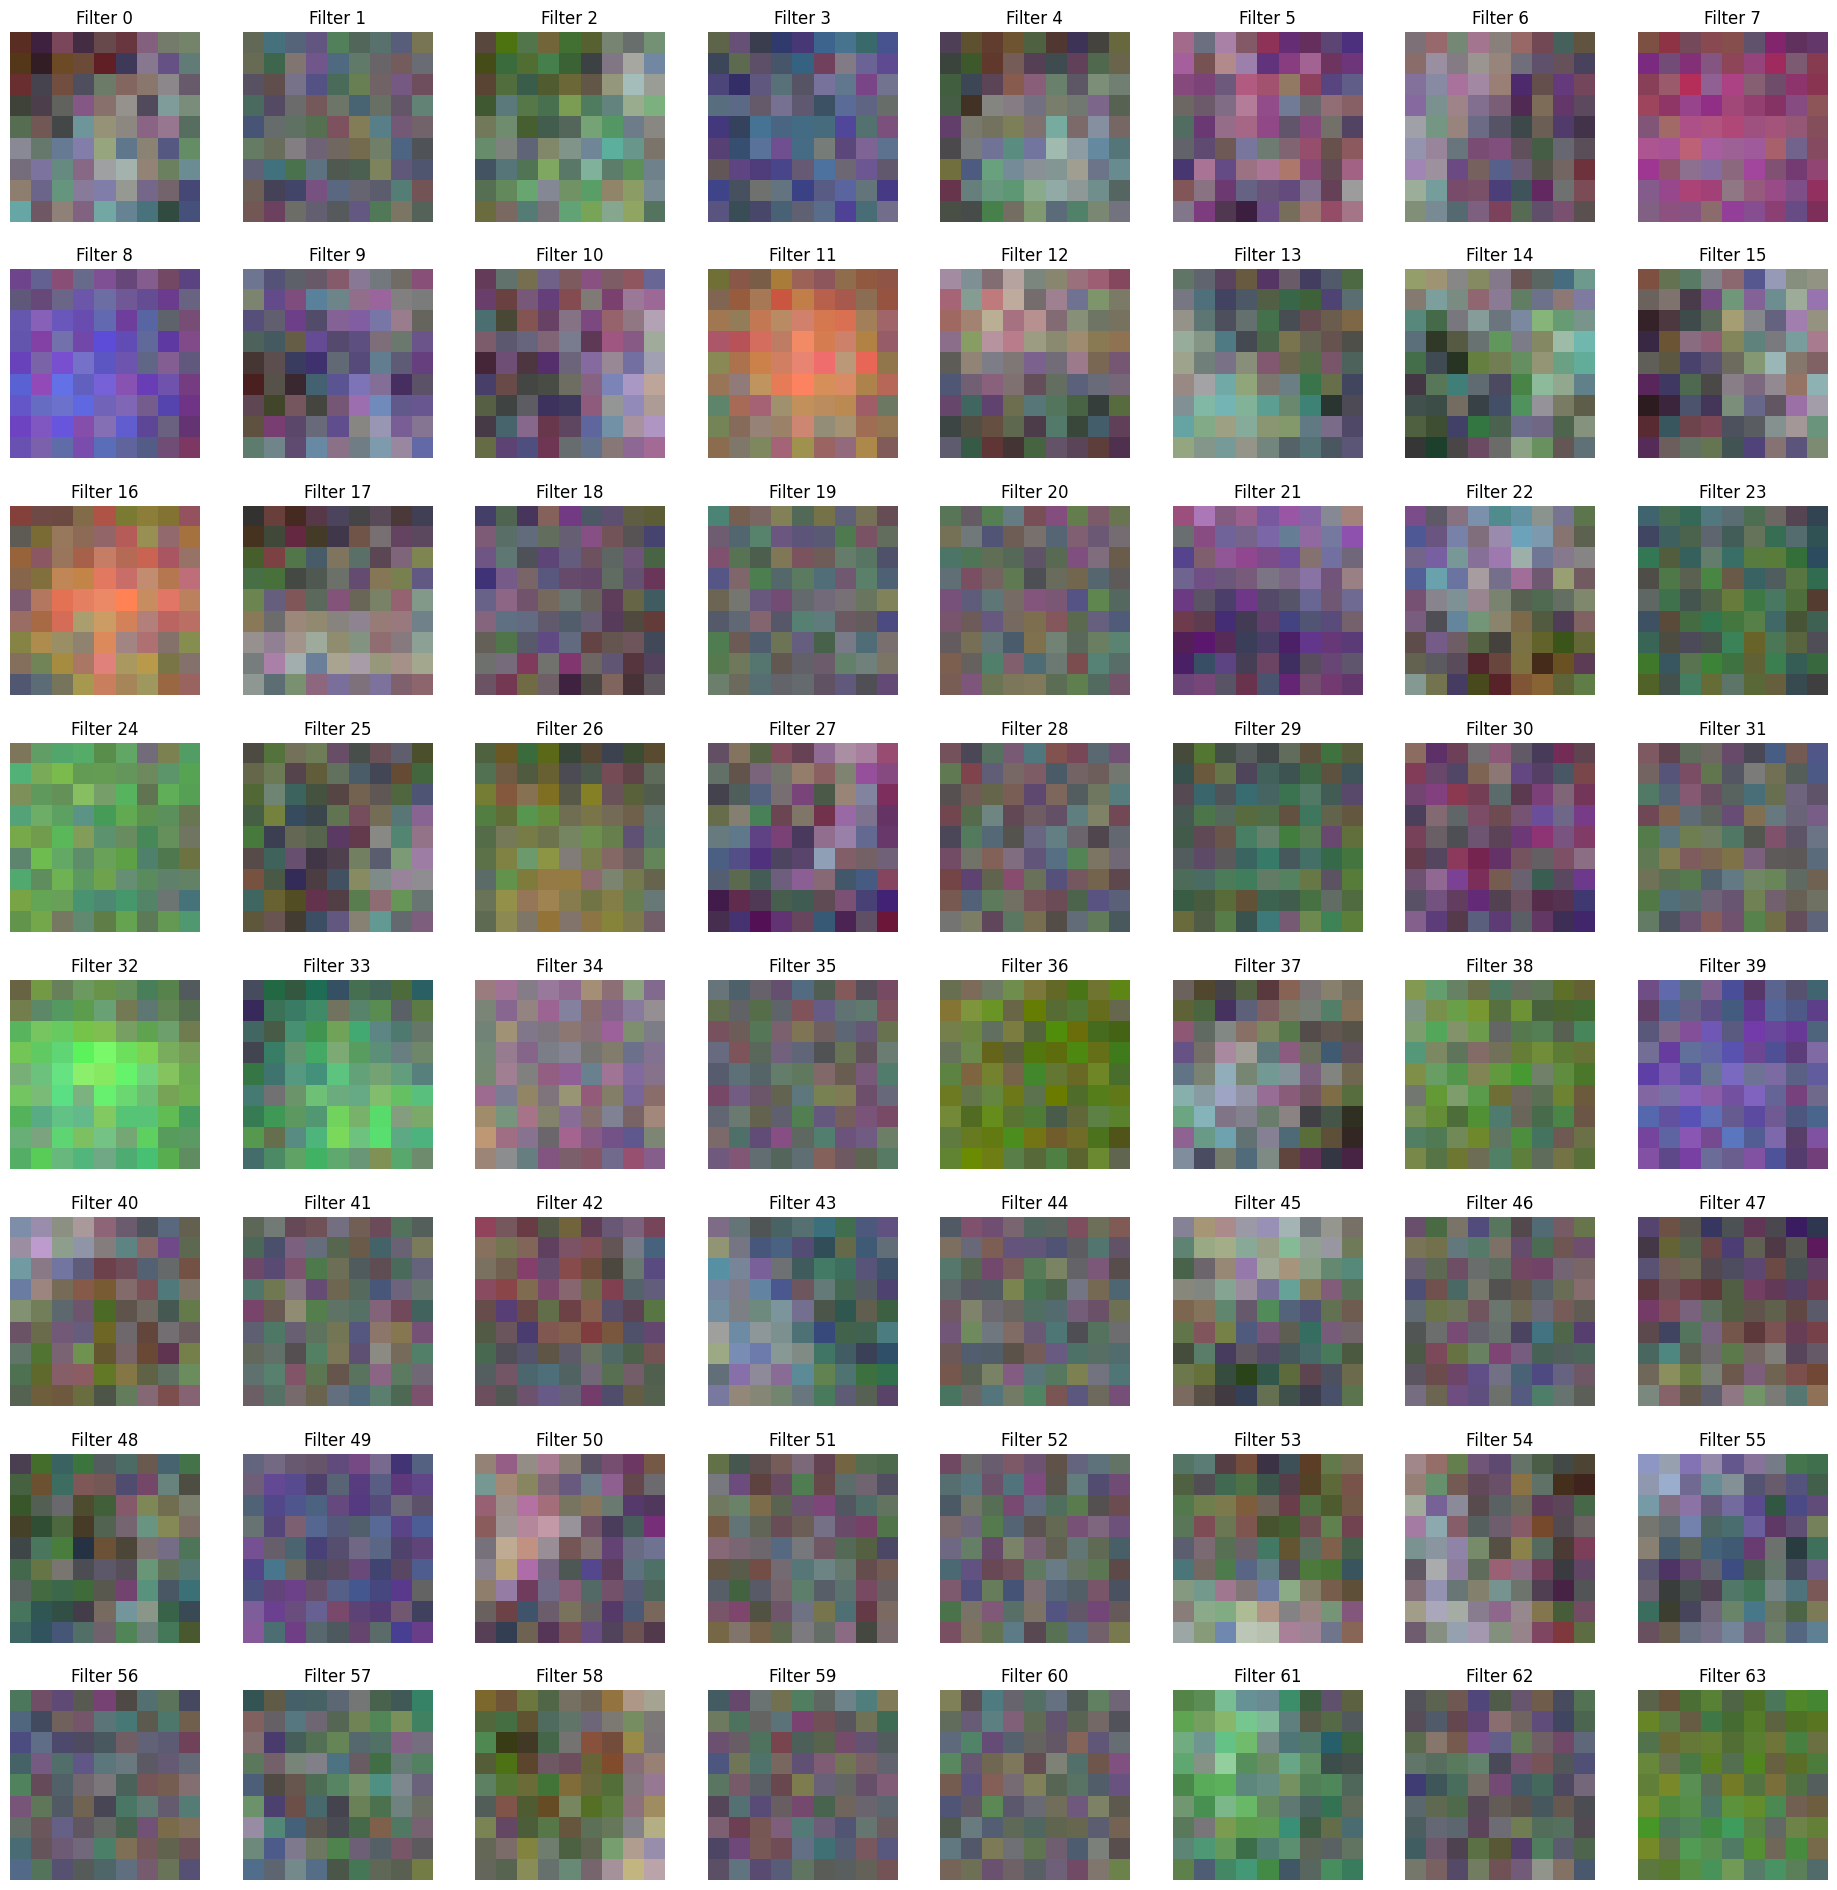

In [20]:
from sklearn.preprocessing import MinMaxScaler

conv_layers = [l.name for l in classifier.layers if isinstance(l, Conv2D)]
cnn11 = conv_layers[0]  # اسم أول طبقة Conv2D
w = classifier.get_layer(name=cnn11).get_weights()[0]  # الفلاتر
wshape = w.shape

scaler = MinMaxScaler()
scaler.fit(w.reshape(-1, 1))
w = scaler.transform(w.reshape(-1, 1))
w = w.reshape(wshape)

n_filters = w.shape[-1]
n_cols = 8
n_rows = int(np.ceil(n_filters / n_cols))

fig, axs = plt.subplots(n_rows, n_cols, figsize=(24, 3 * n_rows))
fig.subplots_adjust(hspace=.25, wspace=.001)
axs = axs.ravel()
for i in range(n_filters):
    h = w[:, :, :, i]
    axs[i].imshow(h)
    axs[i].set_title('Filter ' + str(i))
    axs[i].axis('off')
for j in range(n_filters, len(axs)):
    axs[j].axis('off')
plt.show()